# Pythia/FastJet CAB 2D Flavor Ratio

This notebook uses the same generated-event flavor setup as `cab_pythia_fastjet_flavor_ratio.ipynb`, but the observable is two-dimensional. For each accepted jet, every Lund declustering with `kT > KT_MIN` is kept. The EEC pair weights are accumulated in `(R_L, pT_radiator)` bins, then CAB is computed per bin for b jets and light-quark jets. The primary plot shows `CAB(b jets) / CAB(light-quark jets)` as the color axis.

The x axis is shown in linear `R_L` on a log scale. Internally the `R_L` bins are configured through `ln(R_L)` edges for consistency with the rest of the CAB notebooks.

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import math
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.patheffects as path_effects
from tqdm.auto import tqdm

try:
    import pandas as pd
except ImportError:
    pd = None

REPO_DIR = None
for path in [Path.cwd(), *Path.cwd().parents]:
    if (path / "src" / "cab_eec").is_dir():
        REPO_DIR = path
        break
if REPO_DIR is None:
    raise RuntimeError("run this notebook from the cab repository or a subdirectory")
if str(REPO_DIR / "src") not in sys.path:
    sys.path.insert(0, str(REPO_DIR / "src"))


import heppyyier
heppyyier.load("heppyyier-utils")

from heppyyier_utils.cache import ArtifactCache, safe_token
from heppyyier_utils.pythia import PythiaConfig, create_pythia
from heppyyier_utils.pythia.flavor import (
    FlavorTag,
    append_ghosts,
    extract_hard_partons,
    make_heavy_hadron_ghosts,
    require_hadronization_for_ghost_tagging,
    tag_jet_by_hard_parton,
    tag_jet_by_heavy_hadron_ghosts,
)

from cab_eec.eec import PAIR_KEYS, cab_from_components, denominators_for, wrap_delta_phi
from cab_eec.event_io import Event
from cab_eec.fastjet_backend import FastJetBackend, JetSplitter

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

In [ ]:
N_EVENTS = 50000
ECM_GEV = 13_000.0
PTHAT_MIN = 5.0
PTHAT_MAX = None
PYTHIA_BIAS_ENABLED = True
PYTHIA_BIAS_POWER = 4.0
PYTHIA_BIAS_REF = 50.0
RANDOM_SEED = 12345
HADRONIZATION = True
PRINT_PYTHIA_STAT = True

JET_R = 0.4
JET_PT_MIN = 5.0
JET_PT_MAX = None
ETA_MAX = 1.0e6  # effectively no jet eta cut for this generated-event scan
ETA_MARGIN = 0.0
PT_PARTICLE_MIN = 0.1

FLAVOR_TAG_MODE = "separate_processes"  # "hard_parton", "hadron_ghost", or "separate_processes"
BEAUTY_PROCESS = "hard_qcd_beauty"
LIGHT_PROCESS = "hard_qcd_uds"
FLAVOR_MATCH_RADIUS = 0.3
LIGHT_ABS_IDS = (1, 2, 3)
GLUON_IS_LIGHT = False
CHARM_IS_LIGHT = False
HEAVY_GHOST_SCALE = 1.0e-20
HEAVY_GHOST_USER_INDEX_OFFSET = 10_000_000

RATIO_NUMERATOR = "b"
RATIO_DENOMINATOR = "light"
SAMPLE_LABELS = {
    "b": "b jets",
    "light": "light-quark jets (uds)",
}

ALL_SPLITTINGS_SELECTION = "all_kt_gt_1"
KT_MIN = 1.0
NORMALIZATION = "radiator_pt2"

LNDR_MIN = -5.0
LNDR_MAX = 1.5
N_RL_BINS = 56
RADIATOR_PT_MIN = 5.0
RADIATOR_PT_MAX = 300.0
N_RADIATOR_PT_BINS = 32
RATIO_ZLIM = (1.0e-2, 4.0)
CAB_ZLIM = RATIO_ZLIM
LOG_Z_SCALE = True
LOG_Z_MIN = 1.0e-2
RATIO_COLOR_CENTER = 1.0  # blue below this value, red above it
CAB_COLOR_CENTER = 1.0  # blue below this value, red above it
B_QUARK_MASS_GEV = 4.8
M_OVER_E_LINE_FACTORS = (1.0,)
DRAW_M_OVER_E_LINES = True
MIN_RECORDS_PER_BIN = 3

USE_DISK_CACHE = True
RECOMPUTE_GENERATION = False
RECOMPUTE_2D = False
SAVE_FIGURES = False
OUTPUT_DIR = REPO_DIR / "outputs" / "pythia_fastjet_flavor_2d_ratio"
CACHE_DIR = OUTPUT_DIR / "cache"

Flavor-tag modes match the one-dimensional flavor notebook:

- `hard_parton`: one inclusive hard-QCD sample; jets are matched to outgoing hard partons.
- `hadron_ghost`: one inclusive hard-QCD sample; b jets are tagged by B-hadron ghosts and light jets by hard-parton matching. This requires `HADRONIZATION = True`.
- `separate_processes`: b jets come from `BEAUTY_PROCESS`, light jets from `LIGHT_PROCESS`, and both are still filtered by hard-parton flavor matches.

The split selection is intentionally different from the one-dimensional notebook: this study keeps all Lund declusterings with `split.kt() > KT_MIN`.

In [3]:
CACHE_SCHEMA_VERSION = 1
CACHE = ArtifactCache(CACHE_DIR, schema_version=CACHE_SCHEMA_VERSION, base_dir=REPO_DIR)


def flavor_process_plan() -> list[dict]:
    if FLAVOR_TAG_MODE == "separate_processes":
        return [
            {"process": BEAUTY_PROCESS, "target_sample": "b", "seed_offset": 0},
            {"process": LIGHT_PROCESS, "target_sample": "light", "seed_offset": 1000},
        ]
    return [{"process": "hard_qcd", "target_sample": None, "seed_offset": 0}]


def compact_generation_stem(config: dict) -> str:
    processes = "_".join(item["process"] for item in config.get("process_plan", [])) or "inclusive"
    return safe_token(
        f"{config['flavor_tag_mode']}_{processes}_allktgt{config['kt_min']}"
        f"_nev{config['n_events']}_pthat{config['pthat_min']}_{config['pthat_max']}"
        f"_bias{config['pythia_bias_enabled']}_{config['pythia_bias_power']}_{config['pythia_bias_ref']}"
        f"_seed{config['seed']}"
        f"_R{config['jet_R']}_pt{config['jet_pt_min']}_{config['jet_pt_max']}"
        f"_dr{config['flavor_match_radius']}"
    )


def generation_config() -> dict:
    return {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "generator": "pythia8_pp_flavor_2d_cab_ratio",
        "flavor_tag_mode": FLAVOR_TAG_MODE,
        "process_plan": flavor_process_plan(),
        "n_events": int(N_EVENTS),
        "ecm_gev": float(ECM_GEV),
        "pthat_min": float(PTHAT_MIN),
        "pthat_max": None if PTHAT_MAX is None else float(PTHAT_MAX),
        "pythia_bias_enabled": bool(PYTHIA_BIAS_ENABLED),
        "pythia_bias_power": float(PYTHIA_BIAS_POWER),
        "pythia_bias_ref": float(PYTHIA_BIAS_REF),
        "seed": int(RANDOM_SEED),
        "hadronization": bool(HADRONIZATION),
        "jet_R": float(JET_R),
        "jet_pt_min": float(JET_PT_MIN),
        "jet_pt_max": None if JET_PT_MAX is None else float(JET_PT_MAX),
        "eta_max": float(ETA_MAX),
        "eta_margin": float(ETA_MARGIN),
        "pt_particle_min": float(PT_PARTICLE_MIN),
        "flavor_match_radius": float(FLAVOR_MATCH_RADIUS),
        "light_abs_ids": list(LIGHT_ABS_IDS),
        "gluon_is_light": bool(GLUON_IS_LIGHT),
        "charm_is_light": bool(CHARM_IS_LIGHT),
        "heavy_ghost_scale": float(HEAVY_GHOST_SCALE),
        "heavy_ghost_user_index_offset": int(HEAVY_GHOST_USER_INDEX_OFFSET),
        "all_splittings_selection": ALL_SPLITTINGS_SELECTION,
        "kt_min": float(KT_MIN),
    }


def generation_cache_path(config: dict | None = None) -> Path:
    config = generation_config() if config is None else config
    return CACHE.path("flavor_2d_splitting_records", compact_generation_stem(config), config)


def analysis_config() -> dict:
    records_key = run_info.get("generation_config_hash")
    if records_key is None and "generation_config" in globals():
        records_key = CACHE.digest(generation_config())
    if records_key is None:
        records_key = "unknown_records"
    return {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "records_key": records_key,
        "selection": ALL_SPLITTINGS_SELECTION,
        "kt_min": float(KT_MIN),
        "normalization": NORMALIZATION,
        "lndr_min": float(LNDR_MIN),
        "lndr_max": float(LNDR_MAX),
        "n_rl_bins": int(N_RL_BINS),
        "radiator_pt_min": float(RADIATOR_PT_MIN),
        "radiator_pt_max": float(RADIATOR_PT_MAX),
        "n_radiator_pt_bins": int(N_RADIATOR_PT_BINS),
        "min_records_per_bin": int(MIN_RECORDS_PER_BIN),
    }


def compact_analysis_stem(config: dict) -> str:
    return safe_token(
        f"records{config['records_key']}_allktgt{config['kt_min']}"
        f"_{config['normalization']}_lndr{config['lndr_min']}_{config['lndr_max']}_nrl{config['n_rl_bins']}"
        f"_rpt{config['radiator_pt_min']}_{config['radiator_pt_max']}_npt{config['n_radiator_pt_bins']}"
    )


def analysis_cache_path(config: dict | None = None) -> Path:
    config = analysis_config() if config is None else config
    return CACHE.path("flavor_2d_cab_ratio", compact_analysis_stem(config), config)

In [4]:
def pythia_event_weight(pythia) -> float:
    info = getattr(pythia, "info", None)
    weight = getattr(info, "weight", None)
    if callable(weight):
        try:
            return float(weight())
        except Exception:
            pass
    return 1.0


def pythia_bias_settings() -> tuple[str, ...]:
    if not PYTHIA_BIAS_ENABLED:
        return ()
    return (
        "PhaseSpace:bias2Selection = on",
        f"PhaseSpace:bias2SelectionPow = {float(PYTHIA_BIAS_POWER):g}",
        f"PhaseSpace:bias2SelectionRef = {float(PYTHIA_BIAS_REF):g}",
    )


def pythia_to_cab_event(pythia, event_id: int, *, event_weight: float | None = None) -> Event:
    px: list[float] = []
    py: list[float] = []
    pz: list[float] = []
    energy: list[float] = []
    event = pythia.event
    for index in range(event.size()):
        particle = event[index]
        is_final = bool(particle.isFinal())
        is_visible = bool(particle.isVisible()) if hasattr(particle, "isVisible") else True
        is_parton = bool(particle.isParton()) if hasattr(particle, "isParton") else False
        if is_final and (is_visible or is_parton):
            px.append(float(particle.px()))
            py.append(float(particle.py()))
            pz.append(float(particle.pz()))
            energy.append(float(particle.e()))
    return Event(
        event_id=event_id,
        px=np.asarray(px, dtype=float),
        py=np.asarray(py, dtype=float),
        pz=np.asarray(pz, dtype=float),
        energy=np.asarray(energy, dtype=float),
        weight=pythia_event_weight(pythia) if event_weight is None else float(event_weight),
    )


def create_configured_pythia(process: str, seed_offset: int = 0):
    config = PythiaConfig(
        ecm=ECM_GEV,
        process=process,
        pthat_min=PTHAT_MIN,
        pthat_max=PTHAT_MAX,
        seed=int(RANDOM_SEED) + int(seed_offset),
        hadronization=bool(HADRONIZATION),
        extra_settings=pythia_bias_settings(),
    )
    return create_pythia(config, load=True)


def make_splitter(backend: FastJetBackend) -> JetSplitter:
    jet_cfg = {
        "R": JET_R,
        "pt_min": JET_PT_MIN,
        "pt_max": JET_PT_MAX,
        "eta_max": ETA_MAX,
        "eta_margin": ETA_MARGIN,
        "pt_particle_min": PT_PARTICLE_MIN,
    }
    return JetSplitter(backend, jet_cfg, [{"name": ALL_SPLITTINGS_SELECTION, "mode": "all"}], "candidate")


def cluster_jets(event: Event, pythia_event, backend: FastJetBackend, splitter: JetSplitter, *, with_ghosts: bool):
    particles = backend.particles_from_event(event)
    ghost_labels = {}
    if with_ghosts:
        ghosts, ghost_labels = make_heavy_hadron_ghosts(
            pythia_event,
            backend.fastjet,
            ghost_scale=HEAVY_GHOST_SCALE,
            user_index_offset=HEAVY_GHOST_USER_INDEX_OFFSET,
        )
        append_ghosts(particles, ghosts)
    if particles.size() == 0:
        return [], ghost_labels, None
    cluster_sequence = backend.fastjet.ClusterSequence(particles, splitter.jet_def)
    jets = backend.fastjet.sorted_by_pt(cluster_sequence.inclusive_jets())
    return jets, ghost_labels, cluster_sequence


def flavor_tag_for_jet(jet, pythia_event, hard_partons, ghost_labels):
    if FLAVOR_TAG_MODE == "hadron_ghost":
        ghost_tag = tag_jet_by_heavy_hadron_ghosts(
            jet,
            ghost_labels,
            user_index_offset=HEAVY_GHOST_USER_INDEX_OFFSET,
        )
        if ghost_tag.flavor == "b":
            return ghost_tag
        hard_tag = tag_jet_by_hard_parton(
            jet,
            hard_partons,
            match_radius=FLAVOR_MATCH_RADIUS,
            light_abs_ids=LIGHT_ABS_IDS,
            gluon_is_light=GLUON_IS_LIGHT,
            charm_is_light=CHARM_IS_LIGHT,
        )
        if hard_tag.flavor == "light":
            return hard_tag
        return FlavorTag("unmatched", source="hadron_ghost")
    return tag_jet_by_hard_parton(
        jet,
        hard_partons,
        match_radius=FLAVOR_MATCH_RADIUS,
        light_abs_ids=LIGHT_ABS_IDS,
        gluon_is_light=GLUON_IS_LIGHT,
        charm_is_light=CHARM_IS_LIGHT,
    )


def records_from_jet_all_splittings(splitter: JetSplitter, event: Event, jet, jet_index: int, sample_name: str) -> list:
    records = []
    sequence = list(splitter.lund_gen.result(jet))
    for split_index, split in enumerate(sequence):
        kt = float(split.kt())
        if not kt > float(KT_MIN):
            continue
        record = splitter._record_from_split(event, jet, jet_index, ALL_SPLITTINGS_SELECTION, split)
        if record is not None:
            records.append(replace(record, sample=sample_name))
    return records


def accepted_sample_from_tag(tag, *, target_sample: str | None = None) -> str | None:
    if tag.flavor not in {"b", "light"}:
        return None
    if target_sample is not None and tag.flavor != target_sample:
        return None
    return tag.flavor

In [5]:
# Keep these helpers in the generation cell so rerunning this cell after a
# kernel reset does not depend on a separate cache-helper cell.
CACHE_SCHEMA_VERSION = int(globals().get("CACHE_SCHEMA_VERSION", 1))
CACHE = ArtifactCache(CACHE_DIR, schema_version=CACHE_SCHEMA_VERSION, base_dir=REPO_DIR)


def flavor_process_plan() -> list[dict]:
    if FLAVOR_TAG_MODE == "separate_processes":
        return [
            {"process": BEAUTY_PROCESS, "target_sample": "b", "seed_offset": 0},
            {"process": LIGHT_PROCESS, "target_sample": "light", "seed_offset": 1000},
        ]
    return [{"process": "hard_qcd", "target_sample": None, "seed_offset": 0}]


def compact_generation_stem(config: dict) -> str:
    processes = "_".join(item["process"] for item in config.get("process_plan", [])) or "inclusive"
    return safe_token(
        f"{config['flavor_tag_mode']}_{processes}_allktgt{config['kt_min']}"
        f"_nev{config['n_events']}_pthat{config['pthat_min']}_{config['pthat_max']}"
        f"_bias{config['pythia_bias_enabled']}_{config['pythia_bias_power']}_{config['pythia_bias_ref']}"
        f"_seed{config['seed']}"
        f"_R{config['jet_R']}_pt{config['jet_pt_min']}_{config['jet_pt_max']}"
        f"_dr{config['flavor_match_radius']}"
    )


def generation_config() -> dict:
    return {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "generator": "pythia8_pp_flavor_2d_cab_ratio",
        "flavor_tag_mode": FLAVOR_TAG_MODE,
        "process_plan": flavor_process_plan(),
        "n_events": int(N_EVENTS),
        "ecm_gev": float(ECM_GEV),
        "pthat_min": float(PTHAT_MIN),
        "pthat_max": None if PTHAT_MAX is None else float(PTHAT_MAX),
        "pythia_bias_enabled": bool(PYTHIA_BIAS_ENABLED),
        "pythia_bias_power": float(PYTHIA_BIAS_POWER),
        "pythia_bias_ref": float(PYTHIA_BIAS_REF),
        "seed": int(RANDOM_SEED),
        "hadronization": bool(HADRONIZATION),
        "jet_R": float(JET_R),
        "jet_pt_min": float(JET_PT_MIN),
        "jet_pt_max": None if JET_PT_MAX is None else float(JET_PT_MAX),
        "eta_max": float(ETA_MAX),
        "eta_margin": float(ETA_MARGIN),
        "pt_particle_min": float(PT_PARTICLE_MIN),
        "flavor_match_radius": float(FLAVOR_MATCH_RADIUS),
        "light_abs_ids": list(LIGHT_ABS_IDS),
        "gluon_is_light": bool(GLUON_IS_LIGHT),
        "charm_is_light": bool(CHARM_IS_LIGHT),
        "heavy_ghost_scale": float(HEAVY_GHOST_SCALE),
        "heavy_ghost_user_index_offset": int(HEAVY_GHOST_USER_INDEX_OFFSET),
        "all_splittings_selection": ALL_SPLITTINGS_SELECTION,
        "kt_min": float(KT_MIN),
    }


def generation_cache_path(config: dict | None = None) -> Path:
    config = generation_config() if config is None else config
    return CACHE.path("flavor_2d_splitting_records", compact_generation_stem(config), config)


def generate_records_for_process(process: str, *, target_sample: str | None, seed_offset: int, backend, splitter):
    pythia = create_configured_pythia(process, seed_offset=seed_offset)
    records_by_sample = {"b": [], "light": []}
    stats = {
        "process": process,
        "target_sample": target_sample or "both",
        "generated_events": 0,
        "visible_events": 0,
        "accepted_jets": 0,
        "accepted_splittings": 0,
        "generated_weight_sum": 0.0,
        "accepted_split_weight_sum": 0.0,
        "b_jets": 0,
        "light_jets": 0,
        "unmatched_jets": 0,
        "gluon_jets": 0,
        "charm_jets": 0,
        "other_jets": 0,
    }
    use_ghosts = FLAVOR_TAG_MODE == "hadron_ghost"

    for i_event in tqdm(range(int(N_EVENTS)), desc=f"Pythia {process}", unit="event"):
        if not pythia.next():
            continue
        stats["generated_events"] += 1
        event_weight = pythia_event_weight(pythia)
        stats["generated_weight_sum"] += event_weight
        event = pythia_to_cab_event(pythia, i_event + 1_000_000 * int(seed_offset), event_weight=event_weight)
        if len(event.px) == 0:
            continue
        stats["visible_events"] += 1

        hard_partons = extract_hard_partons(pythia.event)
        jets, ghost_labels, cluster_sequence = cluster_jets(event, pythia.event, backend, splitter, with_ghosts=use_ghosts)
        if cluster_sequence is None:
            continue

        accepted_jet_index = 0
        for jet in jets:
            if not splitter._accept_jet(jet):
                continue
            stats["accepted_jets"] += 1
            tag = flavor_tag_for_jet(jet, pythia.event, hard_partons, ghost_labels)
            stats[f"{tag.flavor}_jets"] = stats.get(f"{tag.flavor}_jets", 0) + 1
            sample_name = accepted_sample_from_tag(tag, target_sample=target_sample)
            if sample_name is not None:
                jet_records = records_from_jet_all_splittings(splitter, event, jet, accepted_jet_index, sample_name)
                records_by_sample[sample_name].extend(jet_records)
                stats["accepted_splittings"] += len(jet_records)
                stats["accepted_split_weight_sum"] += float(sum(record.event_weight for record in jet_records))
            accepted_jet_index += 1

    if PRINT_PYTHIA_STAT:
        pythia.stat()
    return records_by_sample, stats


def merge_records(target: dict[str, list], source: dict[str, list]) -> None:
    for sample_name, records in source.items():
        target.setdefault(sample_name, []).extend(records)


def generate_splitting_records() -> tuple[dict[str, list], dict]:
    if FLAVOR_TAG_MODE not in {"hard_parton", "hadron_ghost", "separate_processes"}:
        raise ValueError(f"unknown FLAVOR_TAG_MODE: {FLAVOR_TAG_MODE!r}")
    if FLAVOR_TAG_MODE == "hadron_ghost":
        require_hadronization_for_ghost_tagging(HADRONIZATION)

    backend = FastJetBackend.load()
    splitter = make_splitter(backend)
    records_by_sample = {"b": [], "light": []}
    stats_by_process = []

    for item in flavor_process_plan():
        records, stats = generate_records_for_process(
            item["process"],
            target_sample=item["target_sample"],
            seed_offset=int(item["seed_offset"]),
            backend=backend,
            splitter=splitter,
        )
        merge_records(records_by_sample, records)
        stats_by_process.append(stats)

    run_info = {
        "attempted_events_per_process": int(N_EVENTS),
        "flavor_tag_mode": FLAVOR_TAG_MODE,
        "process_plan": flavor_process_plan(),
        "all_splittings_selection": ALL_SPLITTINGS_SELECTION,
        "kt_min": float(KT_MIN),
        "flavor_match_radius": float(FLAVOR_MATCH_RADIUS),
        "hadronization": bool(HADRONIZATION),
        "event_weight_source": "pythia.info.weight()",
        "backend_versions": backend.versions(),
        "stats_by_process": stats_by_process,
    }
    return records_by_sample, run_info


def load_or_generate_splitting_records() -> tuple[dict[str, list], dict]:
    config = generation_config()
    config_key = CACHE.digest(config)
    path = generation_cache_path(config)
    if USE_DISK_CACHE and path.exists() and not RECOMPUTE_GENERATION:
        payload = CACHE.read_pickle(path)
        run_info = dict(payload.get("run_info", {}))
        run_info.update({"cache_status": "hit", "generation_config_hash": config_key, "generation_cache_path": CACHE.label(path)})
        print(f"[cache hit] all-splitting flavor records: {CACHE.label(path)}")
        return payload["records_by_sample"], run_info

    records, run_info = generate_splitting_records()
    run_info.update({"cache_status": "miss" if USE_DISK_CACHE else "disabled", "generation_config_hash": config_key, "generation_cache_path": CACHE.label(path)})
    if USE_DISK_CACHE:
        payload = {
            "cache_schema_version": CACHE_SCHEMA_VERSION,
            "generation_config": config,
            "generation_config_hash": config_key,
            "run_info": run_info,
            "records_by_sample": records,
        }
        CACHE.write_pickle(path, payload, sidecar_exclude={"records_by_sample"})
        print(f"[cache save] all-splitting flavor records: {CACHE.label(path)}")
    return records, run_info


records_by_sample, run_info = load_or_generate_splitting_records()
run_info

[cache hit] all-splitting flavor records: outputs/pythia_fastjet_flavor_2d_ratio/cache/flavor_2d_splitting_records__separate_processes_hard_qcd_beauty_hard_qcd_uds_allktgt1p0_nev5000_pthat5p0_None_biasTrue_4p0_50p0_seed12345_R0p4_pt5p0_None_dr0p3__5c2374865d4a.pkl


{'attempted_events_per_process': 5000,
 'flavor_tag_mode': 'separate_processes',
 'process_plan': [{'process': 'hard_qcd_beauty',
   'target_sample': 'b',
   'seed_offset': 0},
  {'process': 'hard_qcd_uds', 'target_sample': 'light', 'seed_offset': 1000}],
 'all_splittings_selection': 'all_kt_gt_1',
 'kt_min': 1.0,
 'flavor_match_radius': 0.3,
 'hadronization': True,
 'event_weight_source': 'pythia.info.weight()',
 'backend_versions': {'fastjet': 'FastJet version 3.5.1',
  'fjcontrib': 'unknown'},
 'stats_by_process': [{'process': 'hard_qcd_beauty',
   'target_sample': 'b',
   'generated_events': 5000,
   'visible_events': 5000,
   'accepted_jets': 41658,
   'accepted_splittings': 13197,
   'generated_weight_sum': 505578.1904332146,
   'accepted_split_weight_sum': 68041.42752694024,
   'b_jets': 6850,
   'light_jets': 0,
   'unmatched_jets': 34808,
   'gluon_jets': 0,
   'charm_jets': 0,
   'other_jets': 0},
  {'process': 'hard_qcd_uds',
   'target_sample': 'light',
   'generated_events

In [6]:
def mean_or_nan(values: list[float]) -> float:
    return float(np.mean(values)) if values else float("nan")


def radiator_pt(record) -> float:
    return float(record.parent_pt) if record.parent_pt is not None else float(record.pt_a + record.pt_b)


def summarize_records(records_by_sample: dict[str, list]) -> list[dict[str, float | int | str]]:
    rows = []
    for sample_name, records in records_by_sample.items():
        rows.append(
            {
                "sample": sample_name,
                "label": SAMPLE_LABELS.get(sample_name, sample_name),
                "selection": ALL_SPLITTINGS_SELECTION,
                "kt_min": float(KT_MIN),
                "n_splittings": len(records),
                "n_jets": len({(record.event_id, record.jet_index) for record in records}),
                "mean_jet_pt": mean_or_nan([record.jet_pt for record in records]),
                "mean_radiator_pt": mean_or_nan([radiator_pt(record) for record in records]),
                "mean_Rg": mean_or_nan([record.delta_rg for record in records]),
                "mean_z": mean_or_nan([record.z for record in records]),
                "mean_kt": mean_or_nan([record.kt for record in records]),
            }
        )
    return rows


summary_rows = summarize_records(records_by_sample)
if pd is not None:
    display(pd.DataFrame(summary_rows))
    display(pd.DataFrame(run_info.get("stats_by_process", [])))
else:
    display(summary_rows)
    display(run_info.get("stats_by_process", []))

,sample,label,selection,kt_min,n_splittings,n_jets,mean_jet_pt,mean_radiator_pt,mean_Rg,mean_z,mean_kt
0,b,b jets,all_kt_gt_1,1.0,13197,5863,222.804283,187.075898,0.156195,0.226893,2.763659
1,light,light-quark jets (uds),all_kt_gt_1,1.0,14075,5625,457.195813,389.826409,0.145200,0.172221,4.210887


,process,target_sample,generated_events,visible_events,accepted_jets,accepted_splittings,generated_weight_sum,accepted_split_weight_sum,b_jets,light_jets,unmatched_jets,gluon_jets,charm_jets,other_jets
0,hard_qcd_beauty,b,5000,5000,41658,13197,505578.190433,68041.427527,6850,0,34808,0,0,0
1,hard_qcd_uds,light,5000,5000,43161,14075,455158.238677,35493.999331,318,6942,35363,0,538,0


In [7]:
def rl_edges() -> np.ndarray:
    return np.exp(np.linspace(float(LNDR_MIN), float(LNDR_MAX), int(N_RL_BINS) + 1))


def radiator_pt_edges() -> np.ndarray:
    return np.linspace(float(RADIATOR_PT_MIN), float(RADIATOR_PT_MAX), int(N_RADIATOR_PT_BINS) + 1)


class EEC2DAccumulator:
    def __init__(self, rl_edges: np.ndarray, pt_edges: np.ndarray):
        self.rl_edges = np.asarray(rl_edges, dtype=float)
        self.pt_edges = np.asarray(pt_edges, dtype=float)
        if self.rl_edges.ndim != 1 or len(self.rl_edges) < 2:
            raise ValueError("rl_edges must be a 1D array with at least two entries")
        if self.pt_edges.ndim != 1 or len(self.pt_edges) < 2:
            raise ValueError("pt_edges must be a 1D array with at least two entries")
        shape = (len(self.pt_edges) - 1, len(self.rl_edges) - 1)
        self.h = {key: np.zeros(shape, dtype=float) for key in PAIR_KEYS}
        self.h2 = {key: np.zeros(shape, dtype=float) for key in PAIR_KEYS}
        self.entries = np.zeros(shape, dtype=float)
        self.n_records = 0
        self.sum_event_weight = 0.0

    def fill_record(self, record, normalization: str) -> None:
        pt_radiator = radiator_pt(record)
        pt_bin = np.searchsorted(self.pt_edges, pt_radiator, side="right") - 1
        if pt_bin < 0 or pt_bin >= len(self.pt_edges) - 1:
            return
        denominators = denominators_for(record, normalization)
        buf = {key: np.zeros_like(self.h[key]) for key in PAIR_KEYS}
        self._accum_same(buf, "AA", record.parts_a, denominators["AA"], pt_bin)
        self._accum_same(buf, "BB", record.parts_b, denominators["BB"], pt_bin)
        self._accum_cross(buf, record.parts_a, record.parts_b, denominators["AB"], pt_bin)
        for key in PAIR_KEYS:
            weighted = buf[key] * record.event_weight
            self.h[key] += weighted
            self.h2[key] += weighted**2
        touched = np.zeros_like(self.entries, dtype=bool)
        for key in ("AA", "BB", "AB"):
            touched |= buf[key] > 0
        self.entries += touched.astype(float)
        self.n_records += 1
        self.sum_event_weight += record.event_weight

    def _accum_same(self, buf: dict[str, np.ndarray], key: str, parts, denom: float, pt_bin: int) -> None:
        if denom <= 0 or len(parts) < 2:
            return
        pt = np.asarray(parts.pt, dtype=float)
        eta = np.asarray(parts.eta, dtype=float)
        phi = np.asarray(parts.phi, dtype=float)
        deta = eta[:, None] - eta[None, :]
        dphi = wrap_delta_phi(phi[:, None] - phi[None, :])
        dr = np.hypot(deta, dphi)
        weights = (pt[:, None] * pt[None, :]) / denom
        mask = ~np.eye(len(pt), dtype=bool)
        self._add_pairs(buf, key, dr[mask], weights[mask], pt_bin)

    def _accum_cross(self, buf: dict[str, np.ndarray], parts_a, parts_b, denom: float, pt_bin: int) -> None:
        if denom <= 0 or len(parts_a) == 0 or len(parts_b) == 0:
            return
        pt_a = np.asarray(parts_a.pt, dtype=float)
        eta_a = np.asarray(parts_a.eta, dtype=float)
        phi_a = np.asarray(parts_a.phi, dtype=float)
        pt_b = np.asarray(parts_b.pt, dtype=float)
        eta_b = np.asarray(parts_b.eta, dtype=float)
        phi_b = np.asarray(parts_b.phi, dtype=float)
        deta = eta_a[:, None] - eta_b[None, :]
        dphi = wrap_delta_phi(phi_a[:, None] - phi_b[None, :])
        dr = np.hypot(deta, dphi).ravel()
        weights = (2.0 * pt_a[:, None] * pt_b[None, :] / denom).ravel()
        self._add_pairs(buf, "AB", dr, weights, pt_bin)

    def _add_pairs(self, buf: dict[str, np.ndarray], key: str, dr: np.ndarray, weights: np.ndarray, pt_bin: int) -> None:
        valid_dr = dr > 0
        if not np.any(valid_dr):
            return
        idx = np.searchsorted(self.rl_edges, dr[valid_dr], side="right") - 1
        w = weights[valid_dr]
        valid = (idx >= 0) & (idx < len(self.rl_edges) - 1)
        if not np.any(valid):
            return
        np.add.at(buf[key][pt_bin], idx[valid], w[valid])
        np.add.at(buf["all"][pt_bin], idx[valid], w[valid])

    def result(self) -> dict:
        rl_widths = np.diff(self.rl_edges)[None, :]
        pt_widths = np.diff(self.pt_edges)[:, None]
        area = rl_widths * pt_widths
        density = {}
        error = {}
        for key in PAIR_KEYS:
            if self.n_records == 0:
                mean = np.zeros_like(self.h[key])
                sem = np.zeros_like(self.h[key])
            else:
                mean = self.h[key] / self.n_records
                var = np.maximum(self.h2[key] / self.n_records - mean**2, 0.0)
                sem = np.sqrt(var / self.n_records)
            density[key] = mean / area
            error[key] = sem / area
        cab, cab_error = cab_from_components(density, error)
        return {
            "rl_edges": self.rl_edges.copy(),
            "pt_edges": self.pt_edges.copy(),
            "density": density,
            "error": error,
            "cab": cab,
            "cab_error": cab_error,
            "entries": self.entries.copy(),
            "n_records": int(self.n_records),
            "sum_event_weight": float(self.sum_event_weight),
        }

In [8]:
# Keep analysis cache helpers here as well, for the same rerun workflow.
CACHE_SCHEMA_VERSION = int(globals().get("CACHE_SCHEMA_VERSION", 1))
CACHE = ArtifactCache(CACHE_DIR, schema_version=CACHE_SCHEMA_VERSION, base_dir=REPO_DIR)


def analysis_config() -> dict:
    records_key = run_info.get("generation_config_hash")
    if records_key is None and "generation_config" in globals():
        records_key = CACHE.digest(generation_config())
    if records_key is None:
        records_key = "unknown_records"
    return {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "records_key": records_key,
        "selection": ALL_SPLITTINGS_SELECTION,
        "kt_min": float(KT_MIN),
        "normalization": NORMALIZATION,
        "lndr_min": float(LNDR_MIN),
        "lndr_max": float(LNDR_MAX),
        "n_rl_bins": int(N_RL_BINS),
        "radiator_pt_min": float(RADIATOR_PT_MIN),
        "radiator_pt_max": float(RADIATOR_PT_MAX),
        "n_radiator_pt_bins": int(N_RADIATOR_PT_BINS),
        "min_records_per_bin": int(MIN_RECORDS_PER_BIN),
    }


def compact_analysis_stem(config: dict) -> str:
    return safe_token(
        f"records{config['records_key']}_allktgt{config['kt_min']}"
        f"_{config['normalization']}_lndr{config['lndr_min']}_{config['lndr_max']}_nrl{config['n_rl_bins']}"
        f"_rpt{config['radiator_pt_min']}_{config['radiator_pt_max']}_npt{config['n_radiator_pt_bins']}"
    )


def analysis_cache_path(config: dict | None = None) -> Path:
    config = analysis_config() if config is None else config
    return CACHE.path("flavor_2d_cab_ratio", compact_analysis_stem(config), config)


def compute_2d_results(records_by_sample: dict[str, list]) -> dict:
    results = {}
    x_edges = rl_edges()
    y_edges = radiator_pt_edges()
    for sample_name, records in records_by_sample.items():
        accumulator = EEC2DAccumulator(x_edges, y_edges)
        for record in tqdm(records, desc=f"{sample_name} 2D EEC", unit="split"):
            accumulator.fill_record(record, NORMALIZATION)
        results[sample_name] = accumulator.result()
    return results


def load_or_compute_2d_results(records_by_sample: dict[str, list]) -> tuple[dict, dict]:
    config = analysis_config()
    config_key = CACHE.digest(config)
    path = analysis_cache_path(config)
    if USE_DISK_CACHE and path.exists() and not RECOMPUTE_2D:
        payload = CACHE.read_pickle(path)
        print(f"[cache hit] 2D CAB table: {CACHE.label(path)}")
        return payload["results_by_sample"], payload.get("analysis_info", {})

    results = compute_2d_results(records_by_sample)
    analysis_info = {
        "analysis_config_hash": config_key,
        "analysis_cache_path": CACHE.label(path),
        "normalization": NORMALIZATION,
        "kt_min": float(KT_MIN),
        "samples": {
            sample: {
                "n_records": result["n_records"],
                "sum_event_weight": result["sum_event_weight"],
            }
            for sample, result in results.items()
        },
    }
    if USE_DISK_CACHE:
        payload = {
            "cache_schema_version": CACHE_SCHEMA_VERSION,
            "analysis_config": config,
            "analysis_config_hash": config_key,
            "analysis_info": analysis_info,
            "results_by_sample": results,
        }
        CACHE.write_pickle(path, payload, sidecar_exclude={"results_by_sample"})
        print(f"[cache save] 2D CAB table: {CACHE.label(path)}")
    return results, analysis_info


results_by_sample, analysis_info = load_or_compute_2d_results(records_by_sample)
analysis_info

[cache hit] 2D CAB table: outputs/pythia_fastjet_flavor_2d_ratio/cache/flavor_2d_cab_ratio__records5c2374865d4a_allktgt1p0_radiator_pt2_lndrm5p0_1p5_nrl56_rpt5p0_300p0_npt32__b7bf970c188b.pkl


{'analysis_config_hash': 'b7bf970c188b',
 'analysis_cache_path': 'outputs/pythia_fastjet_flavor_2d_ratio/cache/flavor_2d_cab_ratio__records5c2374865d4a_allktgt1p0_radiator_pt2_lndrm5p0_1p5_nrl56_rpt5p0_300p0_npt32__b7bf970c188b.pkl',
 'normalization': 'radiator_pt2',
 'kt_min': 1.0,
 'samples': {'b': {'n_records': 10824, 'sum_event_weight': 68041.08852769881},
  'light': {'n_records': 7576, 'sum_event_weight': 35493.404351876656}}}

In [9]:
def ratio_with_uncertainty(numerator, numerator_err, denominator, denominator_err):
    n = np.asarray(numerator, dtype=float)
    sn = np.asarray(numerator_err, dtype=float)
    d = np.asarray(denominator, dtype=float)
    sd = np.asarray(denominator_err, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(d != 0, n / d, np.nan)
        rel_n = np.where(n != 0, sn / n, 0.0)
        rel_d = np.where(d != 0, sd / d, 0.0)
        ratio_err = np.abs(ratio) * np.sqrt(rel_n**2 + rel_d**2)
    ratio_err = np.where(np.isfinite(ratio), ratio_err, np.nan)
    return ratio, ratio_err


def sample_result(sample: str) -> dict:
    result = results_by_sample.get(sample)
    if result is None:
        raise KeyError(f"missing sample {sample!r}")
    return result


def cab_ratio_2d() -> tuple[np.ndarray, np.ndarray]:
    num = sample_result(RATIO_NUMERATOR)
    den = sample_result(RATIO_DENOMINATOR)
    ratio, ratio_err = ratio_with_uncertainty(num["cab"], num["cab_error"], den["cab"], den["cab_error"])
    enough = (num["entries"] >= MIN_RECORDS_PER_BIN) & (den["entries"] >= MIN_RECORDS_PER_BIN)
    ratio = np.where(enough, ratio, np.nan)
    ratio_err = np.where(enough, ratio_err, np.nan)
    return ratio, ratio_err


def flatten_2d_table() -> list[dict]:
    rows = []
    ratio, ratio_err = cab_ratio_2d()
    reference = sample_result(RATIO_NUMERATOR)
    x_edges = reference["rl_edges"]
    y_edges = reference["pt_edges"]
    b = sample_result("b")
    light = sample_result("light")
    for iy in range(len(y_edges) - 1):
        for ix in range(len(x_edges) - 1):
            rows.append(
                {
                    "rl_min": float(x_edges[ix]),
                    "rl_max": float(x_edges[ix + 1]),
                    "rl_center": float(np.sqrt(x_edges[ix] * x_edges[ix + 1])),
                    "radiator_pt_min": float(y_edges[iy]),
                    "radiator_pt_max": float(y_edges[iy + 1]),
                    "radiator_pt_center": float(0.5 * (y_edges[iy] + y_edges[iy + 1])),
                    "cab_b": float(b["cab"][iy, ix]) if np.isfinite(b["cab"][iy, ix]) else np.nan,
                    "cab_b_err": float(b["cab_error"][iy, ix]) if np.isfinite(b["cab_error"][iy, ix]) else np.nan,
                    "cab_light": float(light["cab"][iy, ix]) if np.isfinite(light["cab"][iy, ix]) else np.nan,
                    "cab_light_err": float(light["cab_error"][iy, ix]) if np.isfinite(light["cab_error"][iy, ix]) else np.nan,
                    "cab_b_over_light": float(ratio[iy, ix]) if np.isfinite(ratio[iy, ix]) else np.nan,
                    "cab_b_over_light_err": float(ratio_err[iy, ix]) if np.isfinite(ratio_err[iy, ix]) else np.nan,
                    "entries_b": int(b["entries"][iy, ix]),
                    "entries_light": int(light["entries"][iy, ix]),
                }
            )
    return rows


flat_rows = flatten_2d_table()
if pd is not None:
    display(pd.DataFrame(flat_rows).replace([np.inf, -np.inf], np.nan).dropna(subset=["cab_b_over_light"]).head(10))
else:
    display([row for row in flat_rows if np.isfinite(row["cab_b_over_light"])][:10])

,rl_min,rl_max,rl_center,radiator_pt_min,radiator_pt_max,radiator_pt_center,cab_b,cab_b_err,cab_light,cab_light_err,cab_b_over_light,cab_b_over_light_err,entries_b,entries_light
10,0.021509,0.024156,0.022794,5.0,14.21875,9.609375,0.000000,0.000000,99.881439,122.321207,0.000000,0.000000,13,3
11,0.024156,0.027129,0.025600,5.0,14.21875,9.609375,0.000000,0.000000,2.654567,3.207684,0.000000,0.000000,9,6
14,0.034218,0.038430,0.036263,5.0,14.21875,9.609375,0.000000,0.000000,0.005493,0.006614,0.000000,0.000000,22,6
17,0.048471,0.054437,0.051367,5.0,14.21875,9.609375,0.000002,0.000002,1.105128,1.257817,0.000002,0.000002,40,14
20,0.068661,0.077112,0.072764,5.0,14.21875,9.609375,0.001743,0.001701,0.009898,0.010590,0.176103,0.255023,76,33
21,0.077112,0.086602,0.081719,5.0,14.21875,9.609375,0.023984,0.023395,0.000024,0.000021,1009.468717,1324.867103,108,43
22,0.086602,0.097261,0.091777,5.0,14.21875,9.609375,0.084268,0.047487,0.000085,0.000093,992.790053,1222.453502,114,42
23,0.097261,0.109232,0.103073,5.0,14.21875,9.609375,0.035929,0.019840,0.229436,0.238747,0.156597,0.184475,114,39
24,0.109232,0.122675,0.115758,5.0,14.21875,9.609375,0.068611,0.037552,0.067555,0.060363,1.015639,1.064219,145,53
25,0.122675,0.137774,0.130005,5.0,14.21875,9.609375,0.131252,0.081794,0.074131,0.061729,1.770533,1.841478,156,46


/var/folders/k0/llmhkt1j3dx9rsgmbmwz4tvr0000gn/T/ipykernel_82804/91877943.py:33: RuntimeWarning: divide by zero encountered in log
  out[below] = 0.5 * np.log(masked[below] / self.vmin) / np.log(self.vcenter / self.vmin)


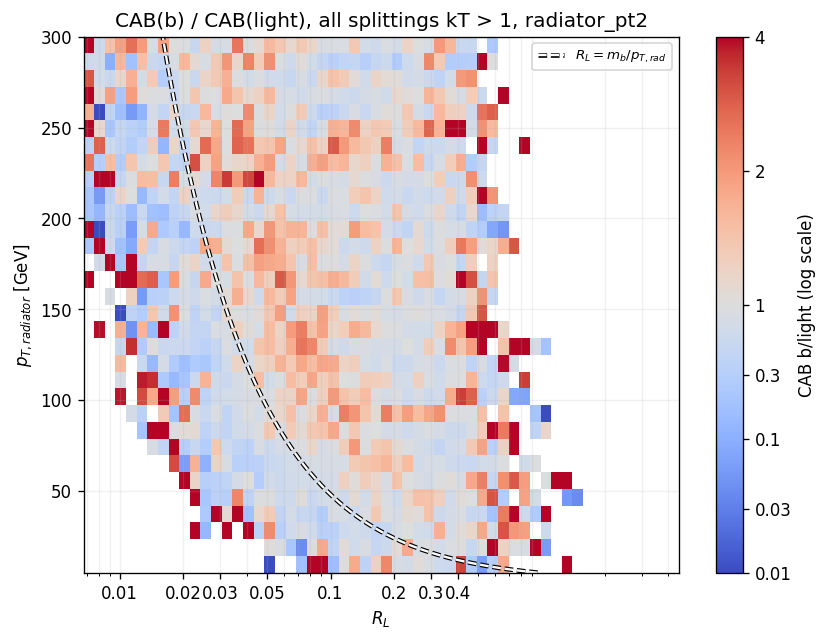

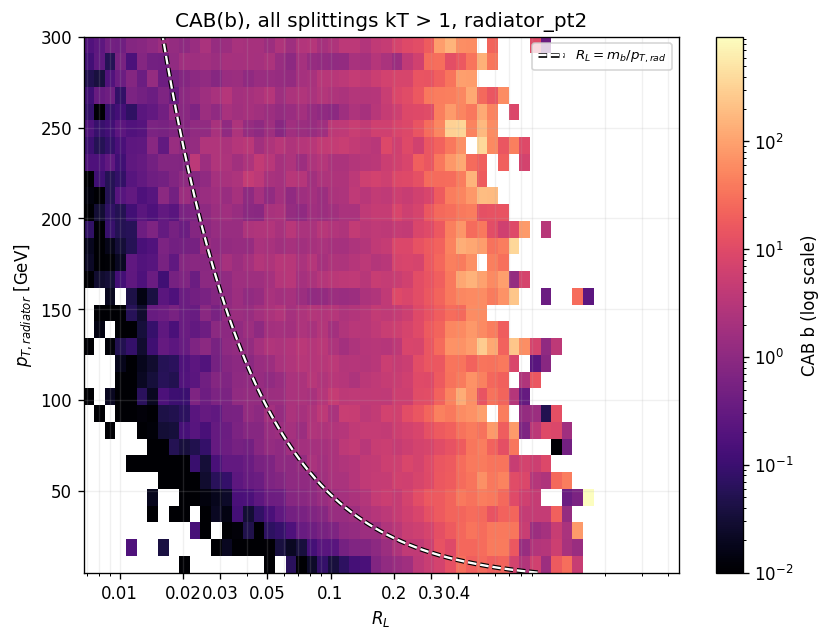

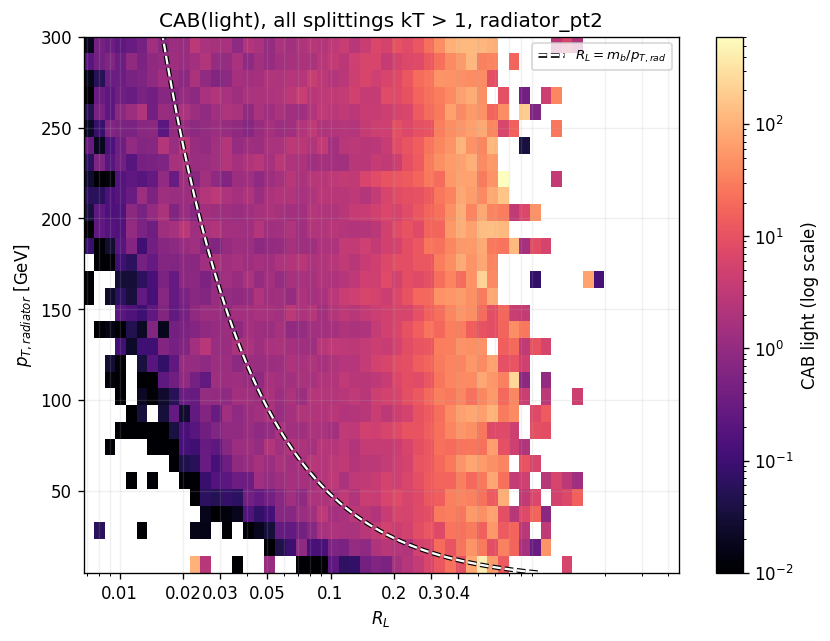

In [10]:
def maybe_save(fig, stem: str) -> None:
    if not SAVE_FIGURES:
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"{stem}.png", bbox_inches="tight")


def format_rl_axis(ax) -> None:
    ax.set_xscale("log")
    ticks = [tick for tick in (0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4) if np.exp(LNDR_MIN) <= tick <= np.exp(LNDR_MAX)]
    if ticks:
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{tick:g}" for tick in ticks])
    ax.set_xlim(np.exp(LNDR_MIN), np.exp(LNDR_MAX))
    ax.set_xlabel(r"$R_L$")


class DivergingLogRatioNorm(Normalize):
    def __init__(self, vmin: float, vcenter: float = 1.0, vmax: float = 4.0, clip: bool = False):
        if not (0.0 < float(vmin) < float(vcenter) < float(vmax)):
            raise ValueError("DivergingLogRatioNorm requires 0 < vmin < vcenter < vmax")
        super().__init__(vmin=float(vmin), vmax=float(vmax), clip=clip)
        self.vcenter = float(vcenter)

    def __call__(self, value, clip=None):
        data = np.ma.asarray(value, dtype=float)
        masked = np.ma.masked_invalid(data)
        masked = np.ma.masked_where(masked < 0, masked)
        scaled = np.ma.clip(masked, self.vmin, self.vmax)
        out = np.ma.masked_all(scaled.shape, dtype=float)
        below = scaled <= self.vcenter
        above = scaled > self.vcenter
        if np.any(below):
            out[below] = 0.5 * np.log(scaled[below] / self.vmin) / np.log(self.vcenter / self.vmin)
        if np.any(above):
            out[above] = 0.5 + 0.5 * np.log(scaled[above] / self.vcenter) / np.log(self.vmax / self.vcenter)
        if clip if clip is not None else self.clip:
            out = np.ma.clip(out, 0.0, 1.0)
        return out

    def inverse(self, value):
        data = np.asarray(value, dtype=float)
        out = np.empty_like(data, dtype=float)
        below = data <= 0.5
        out[below] = self.vmin * (self.vcenter / self.vmin) ** (2.0 * data[below])
        out[~below] = self.vcenter * (self.vmax / self.vcenter) ** (2.0 * (data[~below] - 0.5))
        return out


def z_color_norm(values: np.ndarray, *, vmin=None, vmax=None, log_z: bool = LOG_Z_SCALE):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if not log_z:
        return Normalize(vmin=vmin, vmax=vmax) if vmin is not None or vmax is not None else None
    positive = finite[finite > 0]
    if len(positive) == 0:
        return None
    lo = float(vmin) if vmin is not None and float(vmin) > 0 else max(float(LOG_Z_MIN), float(np.nanmin(positive)))
    hi = float(vmax) if vmax is not None and float(vmax) > lo else float(np.nanmax(positive))
    if not np.isfinite(hi) or hi <= lo:
        hi = lo * 10.0
    return LogNorm(vmin=lo, vmax=hi)


def masked_z_values(values: np.ndarray, *, log_z: bool = LOG_Z_SCALE, mask_nonpositive: bool = True):
    masked = np.ma.masked_invalid(np.asarray(values, dtype=float))
    if log_z and mask_nonpositive:
        masked = np.ma.masked_where(masked <= 0, masked)
    return masked


def draw_m_over_e_lines(ax) -> None:
    if not DRAW_M_OVER_E_LINES:
        return
    y_min, y_max = ax.get_ylim()
    y_min = max(float(y_min), 1.0e-6)
    y_max = max(float(y_max), y_min * 1.01)
    pt = np.geomspace(y_min, y_max, 256)
    x_min, x_max = ax.get_xlim()
    effects = [path_effects.Stroke(linewidth=2.8, foreground="black"), path_effects.Normal()]
    for factor in M_OVER_E_LINE_FACTORS:
        factor = float(factor)
        rl = factor * float(B_QUARK_MASS_GEV) / pt
        visible = (rl >= x_min) & (rl <= x_max)
        if not np.any(visible):
            continue
        label = rf"$R_L = {factor:g}\,m_b/p_{{T,rad}}$" if factor != 1.0 else rf"$R_L = m_b/p_{{T,rad}}$"
        line, = ax.plot(rl[visible], pt[visible], color="white", lw=1.4, ls="--", label=label)
        line.set_path_effects(effects)
    if ax.get_legend_handles_labels()[0]:
        legend = ax.legend(loc="upper right", fontsize=8, frameon=True)
        legend.get_frame().set_alpha(0.8)


def ratio_color_ticks(vmin: float, vmax: float, center: float = 1.0) -> list[float]:
    candidates = [vmin, 0.03, 0.1, 0.3, center, 2.0, vmax]
    ticks = []
    for tick in candidates:
        tick = float(tick)
        if vmin <= tick <= vmax and not any(np.isclose(tick, old) for old in ticks):
            ticks.append(tick)
    return ticks


def plot_heatmap(z: np.ndarray, *, title: str, cbar_label: str, vmin=None, vmax=None, cmap="viridis", log_z: bool = LOG_Z_SCALE, norm=None, cbar_ticks=None, mask_nonpositive: bool = True):
    result = sample_result(RATIO_NUMERATOR)
    x_edges = result["rl_edges"]
    y_edges = result["pt_edges"]
    masked = masked_z_values(z, log_z=log_z, mask_nonpositive=mask_nonpositive)
    fig, ax = plt.subplots(figsize=(8.0, 5.8))
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        masked,
        shading="auto",
        cmap=cmap,
        norm=norm if norm is not None else z_color_norm(z, vmin=vmin, vmax=vmax, log_z=log_z),
    )
    format_rl_axis(ax)
    ax.set_ylabel(r"$p_{T, radiator}$ [GeV]")
    ax.set_ylim(RADIATOR_PT_MIN, RADIATOR_PT_MAX)
    ax.grid(True, alpha=0.18, which="both")
    draw_m_over_e_lines(ax)
    ax.set_title(title)
    scale_note = " (log scale)" if log_z else ""
    colorbar = fig.colorbar(mesh, ax=ax, label=f"{cbar_label}{scale_note}")
    if cbar_ticks is not None:
        colorbar.set_ticks(cbar_ticks)
        colorbar.set_ticklabels([f"{tick:g}" for tick in cbar_ticks])
    return fig


def plot_cab_ratio_2d():
    ratio, _ = cab_ratio_2d()
    fig = plot_heatmap(
        ratio,
        title=f"CAB({RATIO_NUMERATOR}) / CAB({RATIO_DENOMINATOR}), all splittings kT > {KT_MIN:g}, {NORMALIZATION}",
        cbar_label="CAB b/light",
        vmin=RATIO_ZLIM[0],
        vmax=RATIO_ZLIM[1],
        cmap="coolwarm",
        norm=DivergingLogRatioNorm(vmin=RATIO_ZLIM[0], vcenter=RATIO_COLOR_CENTER, vmax=RATIO_ZLIM[1]),
        cbar_ticks=ratio_color_ticks(RATIO_ZLIM[0], RATIO_ZLIM[1], RATIO_COLOR_CENTER),
        mask_nonpositive=False,
    )
    maybe_save(fig, f"cab_pythia_flavor_2d_ratio__{FLAVOR_TAG_MODE}__ktgt{safe_token(KT_MIN)}__{NORMALIZATION}")
    return fig


def plot_sample_cab_2d(sample: str):
    result = sample_result(sample)
    fig = plot_heatmap(
        result["cab"],
        title=f"CAB({sample}), all splittings kT > {KT_MIN:g}, {NORMALIZATION}",
        cbar_label=f"CAB {sample}",
        vmin=CAB_ZLIM[0],
        vmax=CAB_ZLIM[1],
        cmap="coolwarm",
        norm=DivergingLogRatioNorm(vmin=CAB_ZLIM[0], vcenter=CAB_COLOR_CENTER, vmax=CAB_ZLIM[1]),
        cbar_ticks=ratio_color_ticks(CAB_ZLIM[0], CAB_ZLIM[1], CAB_COLOR_CENTER),
        mask_nonpositive=False,
    )
    maybe_save(fig, f"cab_pythia_flavor_2d__{sample}__{FLAVOR_TAG_MODE}__ktgt{safe_token(KT_MIN)}__{NORMALIZATION}")
    return fig


fig_ratio = plot_cab_ratio_2d()
fig_b = plot_sample_cab_2d("b")
fig_light = plot_sample_cab_2d("light")
plt.show()

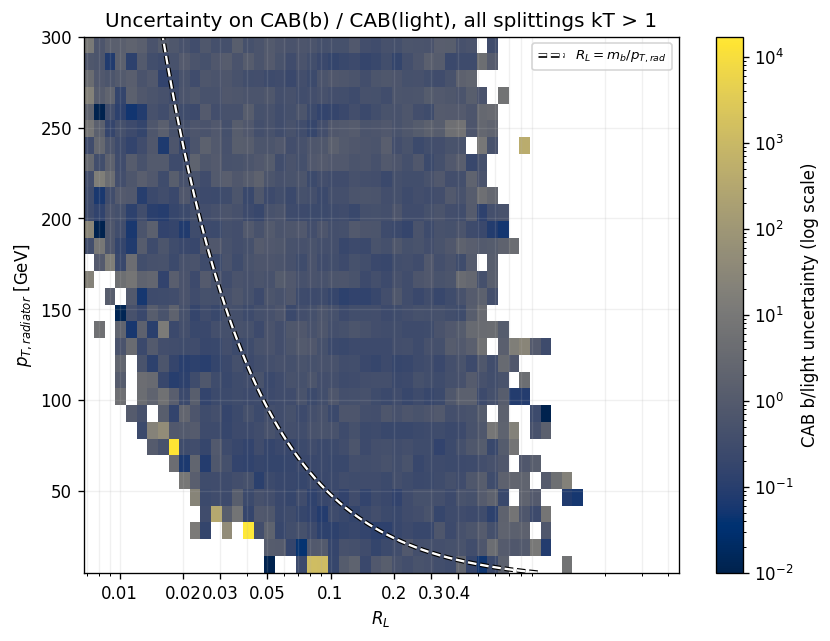

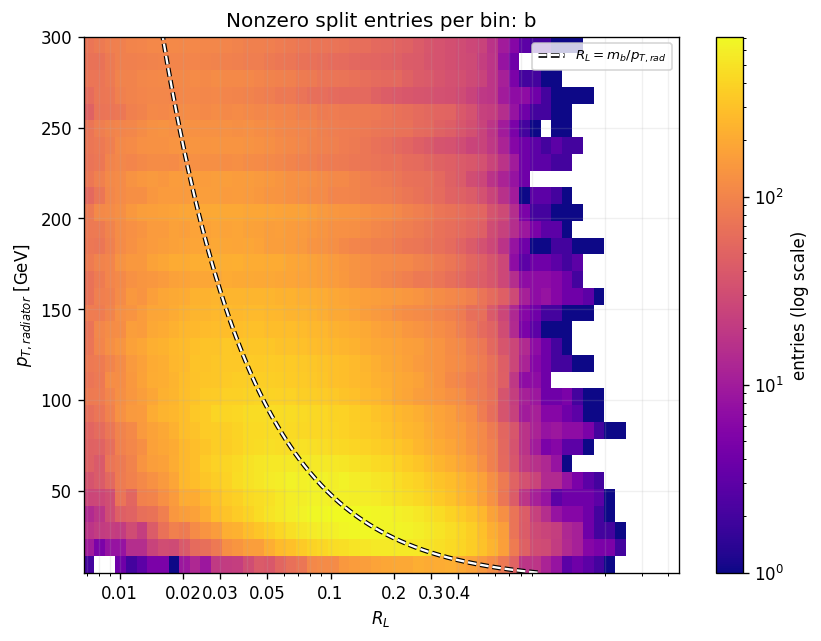

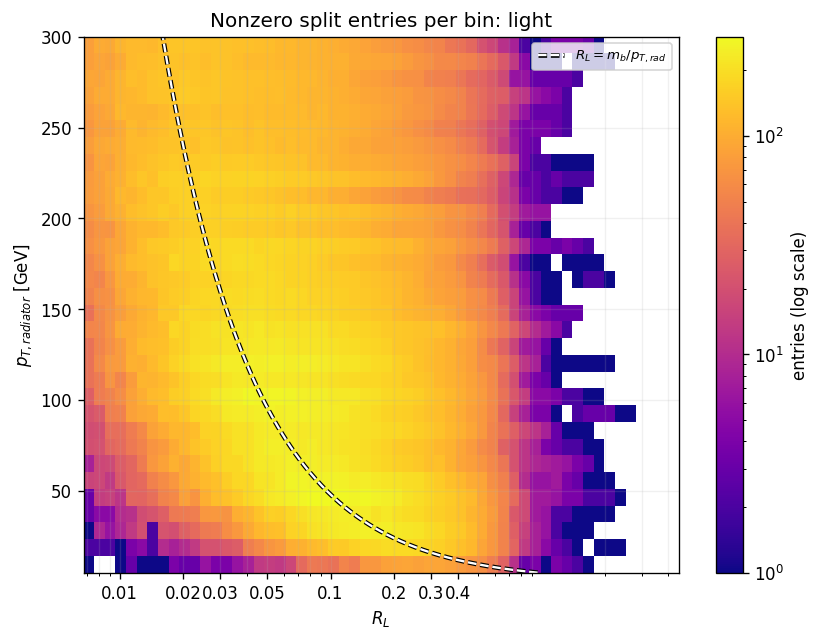

In [11]:
def plot_ratio_error_2d():
    _, ratio_err = cab_ratio_2d()
    fig = plot_heatmap(
        ratio_err,
        title=f"Uncertainty on CAB({RATIO_NUMERATOR}) / CAB({RATIO_DENOMINATOR}), all splittings kT > {KT_MIN:g}",
        cbar_label="CAB b/light uncertainty",
        cmap="cividis",
    )
    maybe_save(fig, f"cab_pythia_flavor_2d_ratio_err__{FLAVOR_TAG_MODE}__ktgt{safe_token(KT_MIN)}__{NORMALIZATION}")
    return fig


def plot_bin_entries(sample: str):
    result = sample_result(sample)
    fig = plot_heatmap(
        result["entries"],
        title=f"Nonzero split entries per bin: {sample}",
        cbar_label="entries",
        cmap="plasma",
    )
    maybe_save(fig, f"cab_pythia_flavor_2d_entries__{sample}__{FLAVOR_TAG_MODE}__ktgt{safe_token(KT_MIN)}")
    return fig


fig_err = plot_ratio_error_2d()
fig_entries_b = plot_bin_entries("b")
fig_entries_light = plot_bin_entries("light")
plt.show()